# Seasonal Agriculture Performance Analysis
---

## Project Description

This project analyzes **4,000 farm records across 8 Indian states** to understand how agricultural performance — yield, production, and profitability — varies across the three cropping seasons: **Kharif, Rabi, and Zaid**.

Using data cleaning, exploratory analysis, statistical comparison, and visualization in Python (Pandas, Matplotlib, Seaborn), the project identifies a clear seasonal risk pattern: **loss rates rise from 42% (Kharif) to 65% (Zaid)**. This decline is traced back to its root cause — Zaid's harsher environmental conditions (lowest rainfall, lowest soil moisture, highest temperature) reduce yield despite farmers using the most irrigation water of any season, resulting in the lowest water-use efficiency.

The final output is a documented Jupyter Notebook with data-driven insights and recommendations to support better seasonal agricultural planning.

### End Users
This analysis is intended for **agricultural policymakers, extension officers, farmers, and rural finance/insurance providers** — stakeholders who require season-specific, evidence-based insights to guide resource allocation, farming advisories, and risk assessment decisions.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.shape

(4000, 28)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 2. Explore & Understand the Dataset

Before cleaning, we check category balance, unique values, and overall structure.

In [4]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [5]:
df['Crop'].unique()

<StringArray>
['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli', 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

In [6]:
df['Irrigation_Method'].unique()

<StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

In [7]:
df['State'].unique()

<StringArray>
['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka', 'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00",...,"4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,...,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,...,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,...,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [9]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

**Observation:** Season counts are imbalanced (Kharif 1779, Rabi 1627, Zaid 594 — Zaid is ~15% of the data). No duplicate or inconsistent category labels found. Missing values exist in three columns: `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`.

In [10]:
df.duplicated().sum(), df['Farm_ID'].duplicated().sum()

(np.int64(0), np.int64(0))

## 3. Data Cleaning

### 3.1 Check where missing values fall (per season)
We check whether nulls cluster within a specific season before deciding an imputation strategy.

In [11]:
df.groupby('Season')[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].apply(lambda x: x.isnull().sum())

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


Missingness is roughly proportional to each season's share of the data — i.e., missing completely at random (MCAR), not clustered in one season. Even so, we impute **per-season** (not globally) to preserve each season's true distribution, since seasonal comparison is the whole point of this analysis.

### 3.2 Impute missing values using per-season median

In [12]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum().sum()  # should be 0

np.int64(0)

### 3.3 Check for logically impossible values

In [13]:
bad = df[(df['Rainfall_mm'] < 0) | (df['Yield_Tonnes_Ha'] < 0) | (df['Farm_Area_Hectares'] <= 0)]
len(bad)

0

**Cleaning complete.** No nulls remain, no duplicates, no logically impossible values.

### 3.4 Add a loss flag for later analysis

In [14]:
df['Loss_Flag'] = df['Profit_INR'] < 0

## 4. Economic Analysis

### 4.1 Revenue, Cost, and Profit by Season

In [15]:
df.groupby('Season')[['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER)

Revenue_INR                       Total_Cost_INR                       Profit_INR                      
              mean     median        std           mean     median        std       mean     median        std
Season                                                                                                        
Kharif  710,719.06 520,196.00 708,710.37     531,804.41 524,840.00 298,487.69 178,914.65  38,808.00 611,549.78
Rabi    601,526.05 438,156.00 584,545.52     513,836.58 506,733.00 288,386.89  87,689.47  -3,187.00 489,901.25
Zaid    519,171.90 373,700.50 509,524.55     543,976.73 534,833.00 297,576.86 -24,804.82 -62,144.00 436,356.75

**Key observations:**
- Mean profit is much higher than median profit in every season — a strong **right-skew** (a small number of high-profit farms pull the average up).
- Rabi's median profit is **negative** even though its mean is positive — more than half of Rabi farms are actually running at a loss.
- Total cost is nearly flat across seasons (~6% variation); the profit decline is driven by **falling revenue**, not rising cost.

### 4.2 % of Farms Operating at a Loss

In [16]:
loss_pct = (df.groupby('Season')['Loss_Flag'].mean() * 100).reindex(SEASON_ORDER)
loss_pct.round(1)

Season
Kharif   42.20
Rabi     51.10
Zaid     64.50
Name: Loss_Flag, dtype: float64

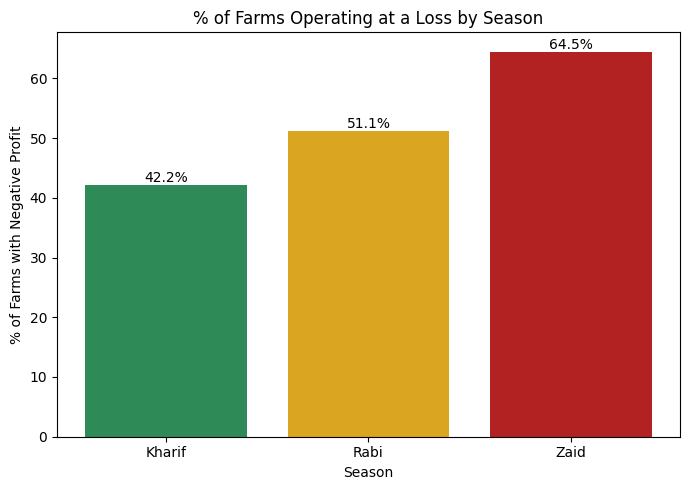

In [17]:
plt.figure(figsize=(7,5))
bars = plt.bar(loss_pct.index, loss_pct.values, color=['#2E8B57', '#DAA520', '#B22222'])
plt.bar_label(bars, fmt='%.1f%%')
plt.title('% of Farms Operating at a Loss by Season')
plt.ylabel('% of Farms with Negative Profit')
plt.xlabel('Season')
plt.tight_layout()
plt.show()

**Finding:** Loss rate rises steadily — 42.2% (Kharif) → 51.1% (Rabi) → 64.5% (Zaid). Nearly 2 in 3 Zaid farms operate at a loss, compared to fewer than half in Kharif.

### 4.3 Profit Distribution (Boxplot)

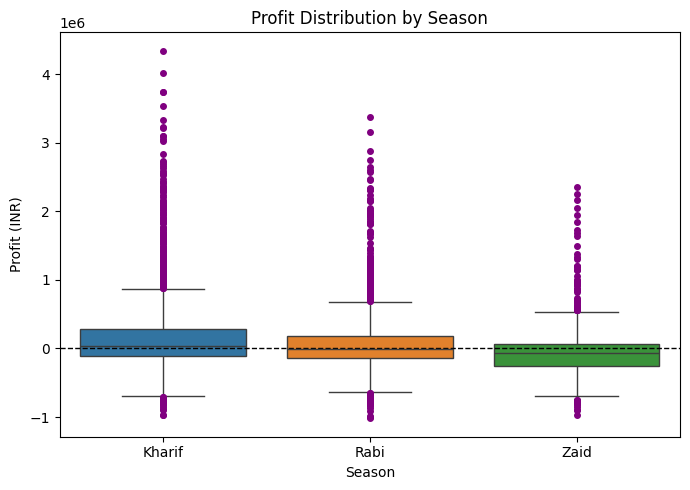

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Season', y='Profit_INR', hue='Season', data=df, order=SEASON_ORDER, legend=False,
            flierprops=dict(markerfacecolor='purple', markeredgecolor='purple', markersize=4))
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit Distribution by Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

**Conclusion (stakeholder-facing):** Zaid season is the biggest financial risk — nearly 2 in 3 farms lose money there, while Kharif remains the most profitable and reliable season. Costs stay similar across seasons, so the drop in Zaid's returns comes from lower revenue, not higher spending.

### 4.4 Cost vs Revenue Relationship

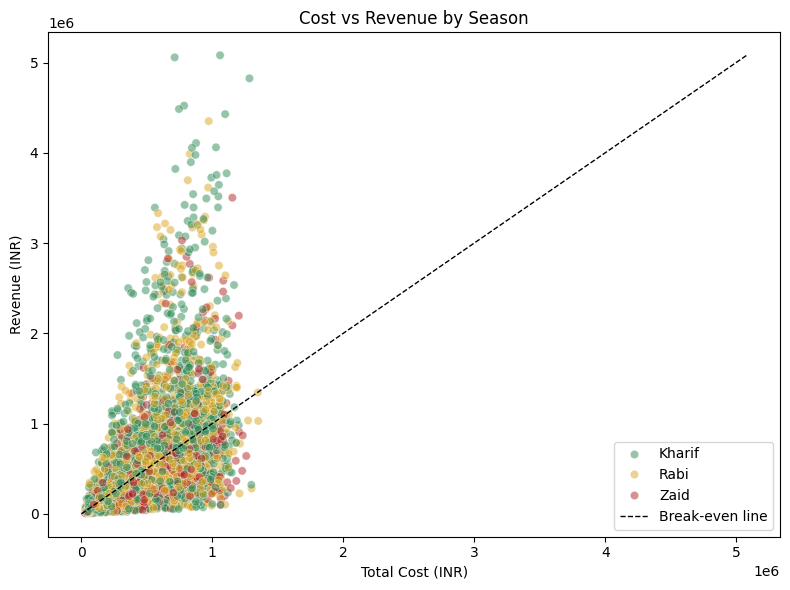

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total_Cost_INR', y='Revenue_INR', hue='Season', hue_order=SEASON_ORDER,
                 data=df, alpha=0.5, palette=['#2E8B57','#DAA520','#B22222'])
max_val = max(df['Total_Cost_INR'].max(), df['Revenue_INR'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1, label='Break-even line')
plt.title('Cost vs Revenue by Season')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.legend()
plt.tight_layout()
plt.show()

Points below the break-even line represent farms operating at a loss. Zaid (red) shows more farms clustered near/below the line compared to Kharif (green).

## 5. Yield & Production Analysis

### 5.1 Yield, Production, and Market Price by Season

In [20]:
df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Market_Price_INR_Tonne']].agg(['mean','median','std']).round(2).reindex(SEASON_ORDER).T

Season                           Kharif      Rabi      Zaid
Yield_Tonnes_Ha        mean        5.63      5.04      4.64
                       median      1.95      1.66      1.45
                       std        14.39     12.75     11.27
Production_Tonnes      mean       46.31     41.49     38.89
                       median     13.24     11.08      9.97
                       std       135.70    121.90    112.00
Market_Price_INR_Tonne mean   44,850.91 44,747.97 44,212.03
                       median 25,793.00 26,041.00 25,749.50
                       std    30,301.56 30,309.56 30,086.23

**Key finding:** Market price is nearly flat across seasons (within ~1.5%), ruling out price as a cause of the profit decline. Instead, both yield and total production decline steadily from Kharif to Zaid (~16-18%) — output volume, not market price, drives the revenue gap.

### 5.2 Rainfall vs Yield

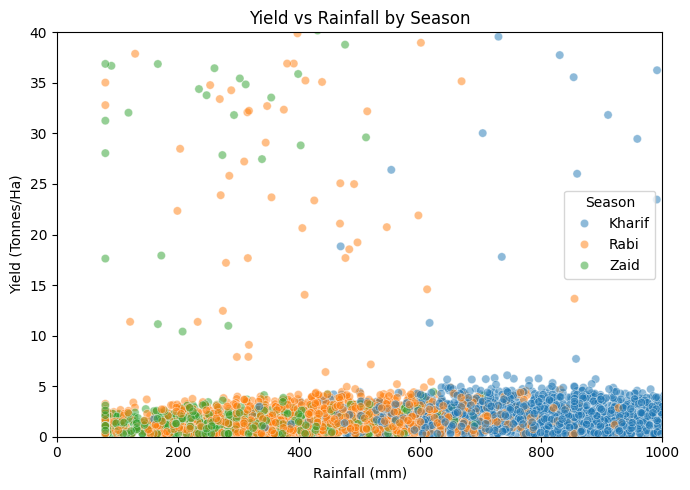

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", data=df, hue="Season",
                 hue_order=SEASON_ORDER, alpha=0.5)
plt.ylim(0,40)
plt.xlim(0,1000)
plt.title("Yield vs Rainfall by Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Stakeholder takeaway:** Higher rainfall raises the *ceiling* of possible yield (Kharif's best farms reach ~40 t/ha vs Zaid's ~30 t/ha), but doesn't guarantee it — most farms in every season still cluster at low yield, showing rainfall is necessary but not sufficient for high yield.

## 6. Environmental Root-Cause Analysis

### 6.1 Environmental & Water-Use Factors by Season

In [22]:
factors = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
           'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
summary = df.groupby('Season')[factors].mean().reindex(SEASON_ORDER)
summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,852.11,28.45,71.81,31.20,"6,102.20",5.89
Rabi,435.94,23.49,57.89,24.05,"5,846.99",5.19
Zaid,299.12,31.04,52.01,19.17,"6,419.89",4.41


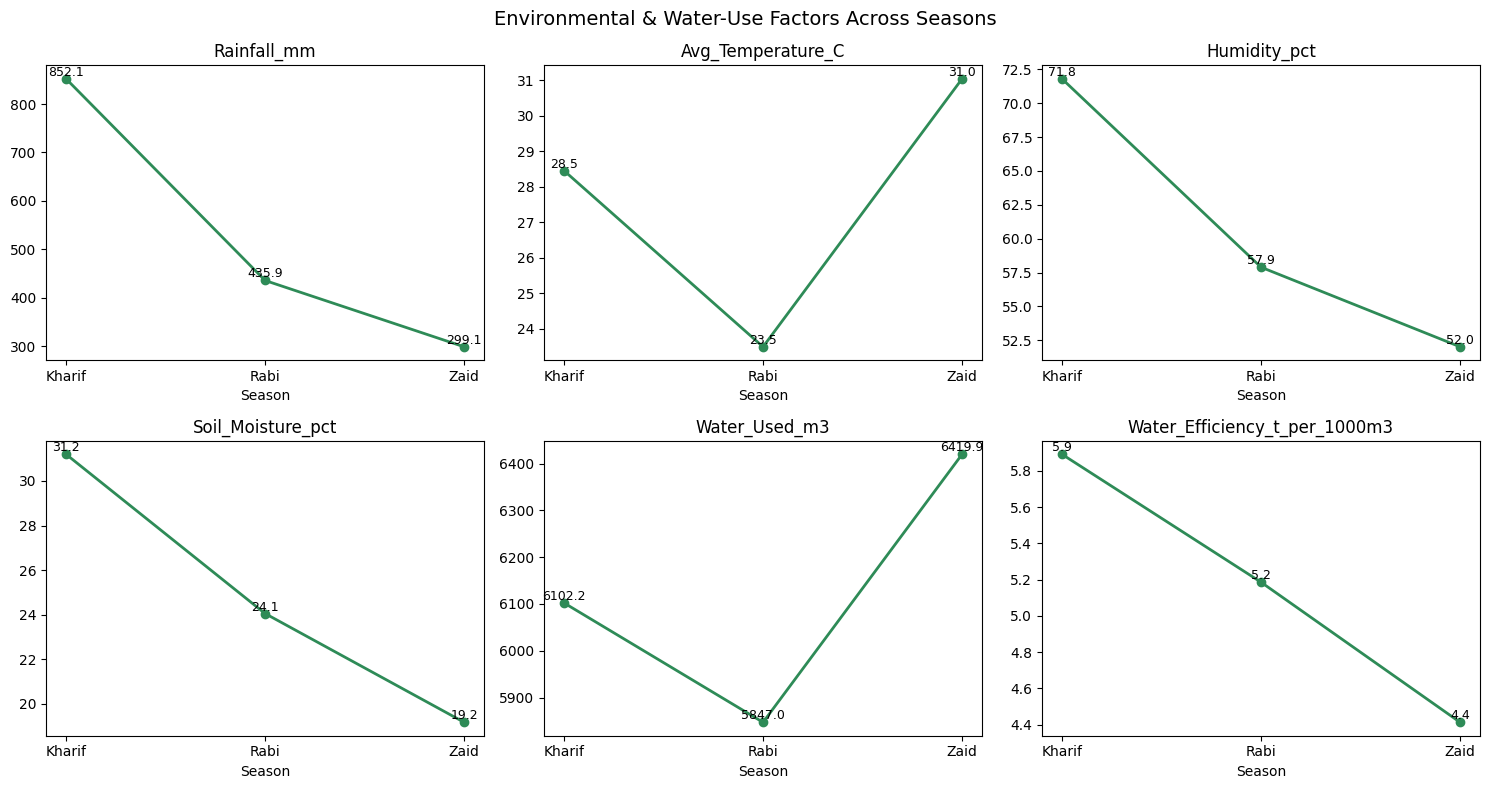

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(factors):
    axes[i].plot(summary.index, summary[col], marker='o', linewidth=2, color='#2E8B57')
    axes[i].set_title(col)
    axes[i].set_xlabel('Season')
    for x, y in zip(summary.index, summary[col]):
        axes[i].text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Environmental & Water-Use Factors Across Seasons', fontsize=14)
plt.tight_layout()
plt.show()

**Key finding:** Zaid combines the lowest rainfall, lowest soil moisture, lowest humidity, **and** the highest average temperature of any season — the most physically stressful growing conditions in the calendar. Despite farmers using the *most* irrigation water in Zaid, water-use efficiency is the *lowest* — more water is not converting into proportional yield.

### 6.2 Does Irrigation Method Explain the Inefficiency?

In [24]:
irr = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(SEASON_ORDER) * 100
irr.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


**Finding:** Irrigation method usage is nearly identical across all three seasons — Zaid farmers aren't relying on worse irrigation technology. This rules out method choice as the cause and confirms the inefficiency is environmentally driven.

## 7. State-Level Comparison (Zaid Season)

### 7.1 Loss Rate by State (within Zaid)

In [25]:
zaid = df[df['Season']=='Zaid']
state_loss = (zaid.groupby('State')['Loss_Flag'].mean() * 100).sort_values(ascending=False)
state_loss.round(1)

State
Gujarat          71.60
Andhra Pradesh   70.60
Maharashtra      68.10
Telangana        65.90
Madhya Pradesh   63.50
Tamil Nadu       62.00
Karnataka        58.10
Punjab           55.80
Name: Loss_Flag, dtype: float64

**Finding:** All 8 states show majority loss rates in Zaid (55–72%), but severity varies — Gujarat and Andhra Pradesh are hit hardest (~70-72%), while Punjab is comparatively more resilient (55.8%).

### 7.2 Punjab vs Gujarat — What's Different?

In [26]:
compare = zaid[zaid['State'].isin(['Punjab','Gujarat'])]
cols = ['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Water_Efficiency_t_per_1000m3','Yield_Tonnes_Ha','Fertilizer_kg_ha']
compare.groupby('State')[cols].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Fertilizer_kg_ha
State,,,,,,
Gujarat,285.81,30.41,18.25,4.10,4.06,194.83
Punjab,294.52,31.19,19.27,4.92,5.91,185.98


**Finding:** Punjab achieves 45% higher yield than Gujarat despite near-identical rainfall, similar (slightly higher) temperature, and even less fertilizer use. This rules out the obvious environmental/input explanations — the gap likely stems from factors outside this dataset (soil quality, regional farming expertise, crop-variety suitability).

## 8. Insights & Recommendations

### Key Insights

1. **Seasonal profitability declines steadily from Kharif to Zaid.** Loss rate rises from 42.2% → 51.1% → 64.5%.
2. **The cause is revenue, not cost.** Total cost is nearly flat across seasons; the decline is driven by falling yield/revenue.
3. **Market price is not a factor.** Price per tonne is nearly flat (within 1.5%) across seasons.
4. **Yield decline traces back to environmental stress.** Zaid has the lowest rainfall, soil moisture, humidity, and highest temperature.
5. **Farmers compensate with more water — but inefficiently.** Zaid has the highest water usage yet the lowest water-use efficiency.
6. **Irrigation method choice isn't the problem.** Method distribution is nearly identical across seasons.
7. **Risk severity varies by state.** Punjab shows resilience that isn't explained by rainfall, temperature, or fertilizer use alone.

### Recommendations

1. **Prioritize Zaid-season support programs**, especially in Gujarat, Andhra Pradesh, and Maharashtra — the states with the highest loss rates.
2. **Invest in heat and drought resilience, not just irrigation volume** — heat-tolerant crop varieties and soil moisture retention techniques (mulching, cover cropping).
3. **Study Punjab's Zaid practices as a model** for other states, since its yield advantage isn't explained by the measured environmental factors.
4. **Introduce season-specific crop insurance or subsidy tiers**, since Zaid's risk profile is structurally different from Kharif or Rabi.
5. **Investigate irrigation *scheduling/timing*, not just method** — research should shift toward *when* and *how much* water is applied relative to Zaid's heat patterns.


## 9. Limitations

- **Single-year snapshot** — unclear whether Zaid's poor performance is a consistent multi-year pattern or specific to this year's weather.
- **State-level gap unexplained** — Punjab's yield advantage over Gujarat isn't accounted for by rainfall, temperature, soil moisture, or fertilizer use in this dataset.
- **No formal causal testing** — patterns and correlations are strong, but formal significance tests (e.g., ANOVA) were not run to confirm differences aren't due to chance.
- **Farm-level detail missing** — no data on farm size category, farmer experience, or access to credit/subsidies.
- **Aggregated water efficiency** — measured as a seasonal/state average, not individual farm-level irrigation scheduling.


## 10. Future Scope

- **Predictive modeling** — forecast yield/profit before the season starts, instead of just explaining past outcomes.
- **Crop and state-level breakdown** — check if Zaid's risk is uniform across all crops/states or concentrated in a few.
- **Multi-year data** — confirm if Zaid's poor performance is a consistent trend or specific to this year's weather.
- **Irrigation method comparison** — quantify how much switching to Drip (vs Flood/Rainfed) could improve Zaid's water efficiency and profit.
- **Farmer-level segmentation** — since 35% of Zaid farms *are* still profitable, study what those farms are doing differently.
